 1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим измерениям.

In [ ]:
import pandas as pd

data = pd.read_csv('abalone.csv')

In [ ]:
data

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,1,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,-1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,1,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,0,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,-1,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,1,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,1,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,-1,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


 2. Преобразуйте признак Sex в числовой: значение F должно перейти в-1, I в 0, M в 1. Если вы используете Pandas, то подойдет 2 следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x == ’M’ else (-1 if x == ’F’ else 0))

In [ ]:
data['Sex'] = data['Sex'].map(lambda x: 1 if x == 'M' else (-1 if x == 'F' else 0))

 3. Разделите содержимое файлов на признаки и целевую переменную.
 В последнем столбце записана целевая переменная, в остальных признаки

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values#таргет

 4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor)
 с различным числом деревьев: от 1 до 50 (random_state=1). Для каждого из вариантов оцените качество работы полученного леса на кросс-валидации по 5 блокам. Используйте параметры "random_state=1"и "shuffle=True"при создании генератора кросс валидации sklearn.cross_validation.KFold. В качестве меры качества воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

In [ ]:
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=1)
results = []

for n_trees in range(1, 51):
    model = RandomForestRegressor(n_estimators=n_trees, random_state=1)
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mean_score = scores.mean()
    results.append((n_trees, mean_score))


In [ ]:
results

[(1, np.float64(0.10967482068860261)),
 (2, np.float64(0.3413000096365689)),
 (3, np.float64(0.406433829066129)),
 (4, np.float64(0.4447745857536912)),
 (5, np.float64(0.46503241426823594)),
 (6, np.float64(0.47139595825898917)),
 (7, np.float64(0.4766658451893487)),
 (8, np.float64(0.4829348394224631)),
 (9, np.float64(0.4894370162945041)),
 (10, np.float64(0.4954085552428177)),
 (11, np.float64(0.4944111155773555)),
 (12, np.float64(0.49902817866563326)),
 (13, np.float64(0.5030578549564464)),
 (14, np.float64(0.5073168234618861)),
 (15, np.float64(0.5091809969556578)),
 (16, np.float64(0.5114105314179662)),
 (17, np.float64(0.5148917747729636)),
 (18, np.float64(0.5172203573170132)),
 (19, np.float64(0.5198293095329432)),
 (20, np.float64(0.51948435033775)),
 (21, np.float64(0.520529096463528)),
 (22, np.float64(0.5208044230080824)),
 (23, np.float64(0.521742855685855)),
 (24, np.float64(0.5231059969795335)),
 (25, np.float64(0.5232486470488318)),
 (26, np.float64(0.5243076139284634

 5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это количество и будет ответом на задание.

In [ ]:
for n_trees, score in results:
    if score > 0.52:
        print(n_trees)
        break


21


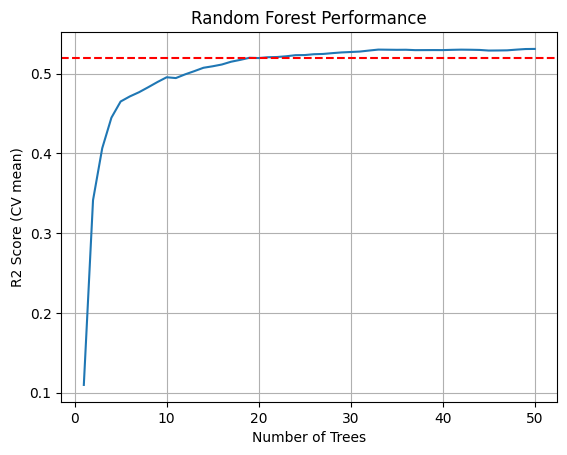

In [ ]:
import matplotlib.pyplot as plt

n_trees_list, score_list = zip(*results)
plt.plot(n_trees_list, score_list)
plt.axhline(0.52, color='red', linestyle='--')
plt.xlabel('Number of Trees')
plt.ylabel('R2 Score (CV mean)')
plt.title('Random Forest Performance')
plt.grid(True)
plt.show()


 6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?

Пока что на таком количестве качество улучшается, но метод почти выжал максимальный скор заметно, чо график выходит на плато к концу графика